In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from tqdm import tqdm
from pathlib import Path

from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pulse_analysis import read_root_file, format_root_data
from pulse_analysis import find_all_pulses, find_pulse_groups

In [16]:
dac_to_pe = [0.000770, 0.000769]
max_events = 10000

filename = '/disk/gfs_atp/lhoetz/marmotx/XDetector_DC_OR_800V/XDetector_DC_OR_800V_Module_0_0.root'
_ar = read_root_file(filename, max_events=max_events)
data = format_root_data(_ar, n_baseline_samples=50, rms_threshold=0.01, dac_to_pe=dac_to_pe)

n = data['wfs_raw'].shape[0]
n_samples = data['wfs_raw'].shape[-1]

Raw file keys: ['t1;8', 't1;7']
Number of events: 10000
Sample length: 200


In [17]:
data['noisy_baseline'].sum()

np.int64(0)

In [18]:
results = find_all_pulses(
    data,
    hi_sigma=3.0,
    lo_sigma=1.5,
    smooth_window=5,
    max_gap=35,
    pad=10,
    min_width=3,
)

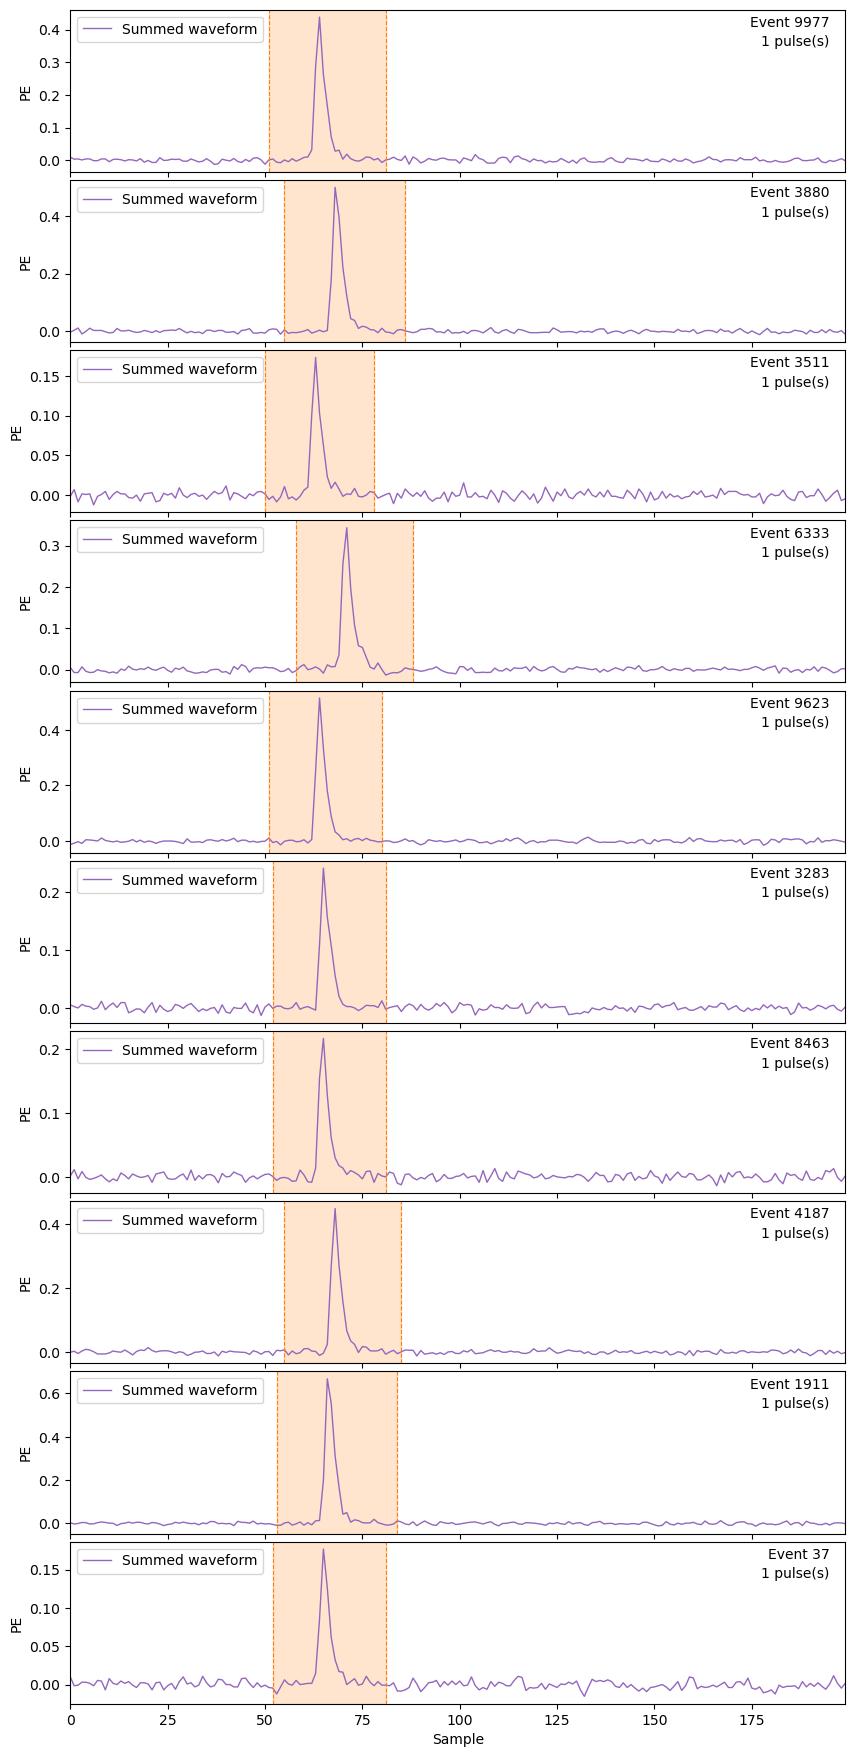

In [19]:
n_plot = 10
indices = np.random.choice(len(data), size=min(n_plot, len(data)), replace=False)

fig, axs = plt.subplots(
    len(indices), 1,
    figsize=(10, 2.2 * len(indices)),
    sharex=True
)

if len(indices) == 1:
    axs = [axs]

for ax, i in zip(axs, indices):
    event_id = data["event_index"][i]

    summed_wf = data["wfs"][i, 0, :] + data["wfs"][i, 1, :]
    pulses, summed, smooth = find_pulse_groups(data[i])

    x = np.arange(len(summed_wf))
    ax.plot(x, summed_wf, color="tab:purple", lw=1, label="Summed waveform")

    for p in pulses:
        ax.axvspan(p["start"], p["end"], color="tab:orange", alpha=0.2)
        ax.axvline(p["start"], color="tab:orange", ls="--", lw=0.8)
        ax.axvline(p["end"], color="tab:orange", ls="--", lw=0.8)

    ax.text(
        0.98, 0.80,
        f"{len(pulses)} pulse(s)",
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=10,
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5),
    )

    ax.text(
        0.98, 0.92,
        f"Event {event_id}",
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=10,
        color="black",
    )

    ax.set_ylabel("PE")
    ax.set_xlim(0, len(summed_wf) - 1)
    ax.legend(loc="upper left")

axs[-1].set_xlabel("Sample")
plt.subplots_adjust(hspace=0.05)
plt.show()

In [20]:
all_sums = []
all_widths = []
all_amps = []

for ev in results:

    pulses = ev["pulses"] if ev["pulses"] else None

    if pulses is not None:
        # unpack into the lists
        for p in pulses:
            all_sums.append(p["sum"])
            all_widths.append(p["width"])
            all_amps.append(p["peak_amplitude"])


# To nunmpy arrays
all_sums = np.array(all_sums)
all_widths = np.array(all_widths)
all_amps = np.array(all_amps)

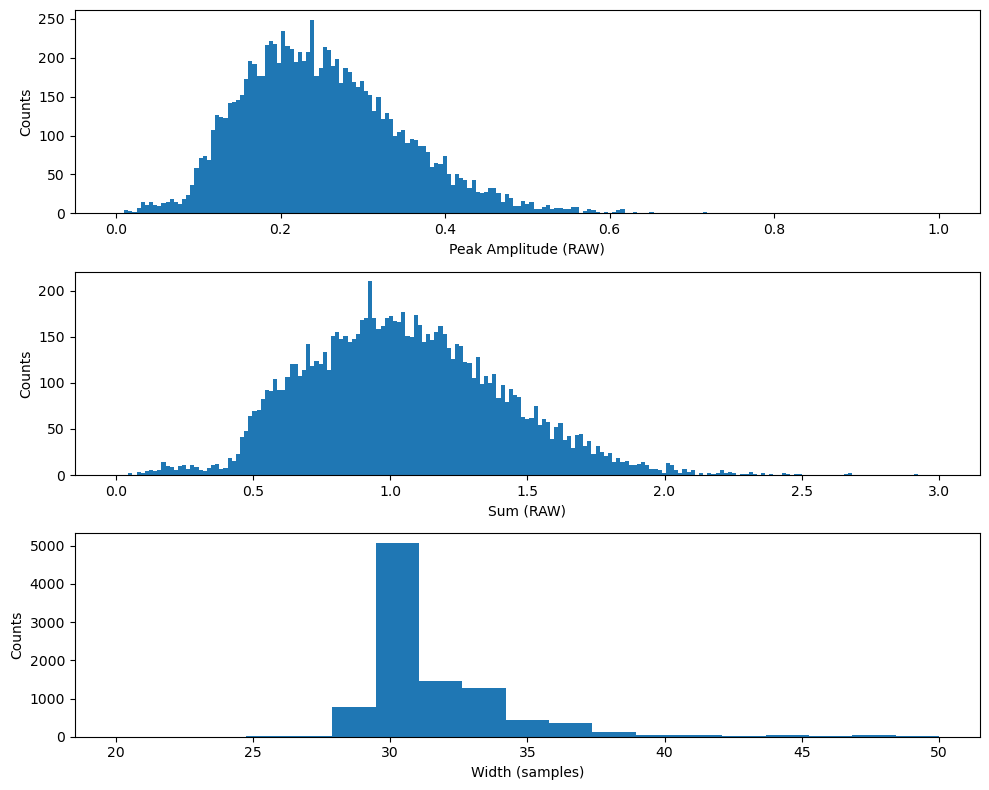

In [25]:
amp_bins = np.linspace(0, 1, 200)
sums_bins = np.linspace(0, 3, 200)
width_bins = np.linspace(20, 50, 20)

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=False)
axs[0].hist(all_amps, bins=amp_bins)
axs[1].hist(all_sums, bins=sums_bins)
axs[2].hist(all_widths, bins=width_bins)

axs[0].set_xlabel("Peak Amplitude (RAW)")
axs[1].set_xlabel("Sum (RAW)")
axs[2].set_xlabel("Width (samples)")
axs[0].set_ylabel("Counts")
axs[1].set_ylabel("Counts")
axs[2].set_ylabel("Counts")
# axs[0].set_yscale("log")
# axs[1].set_yscale("log")
# axs[2].set_yscale("log")

plt.tight_layout()
plt.show()

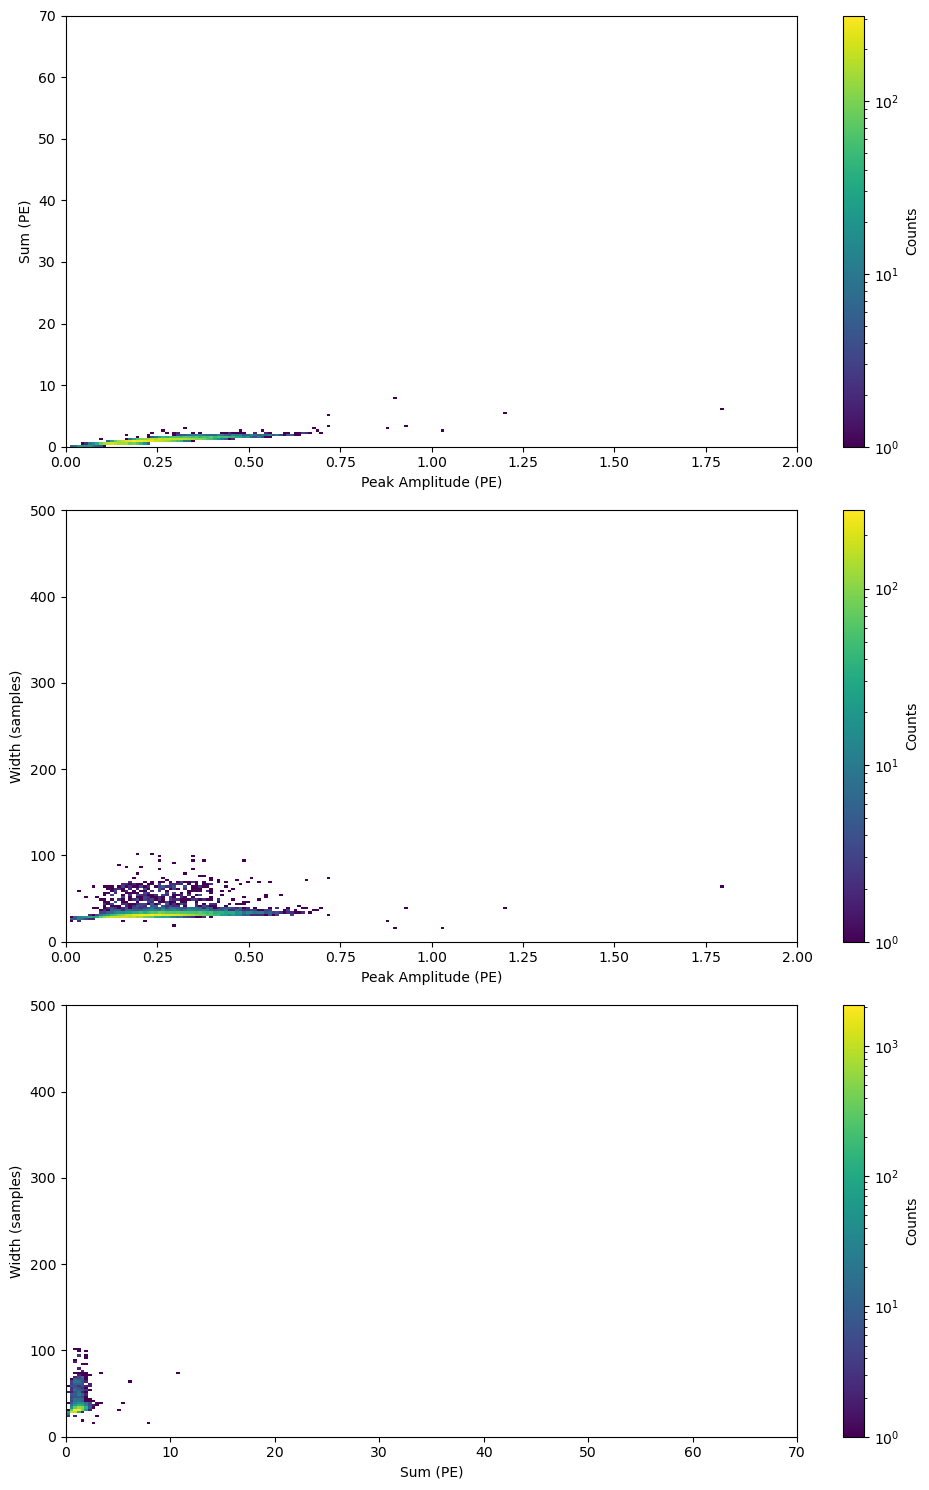

In [26]:
amp_bins = np.linspace(0, 2, 200)
sums_bins = np.linspace(0, 70, 200)
width_bins = np.linspace(0, 500, 200)

fig, axs = plt.subplots(3, 1, figsize=(10, 15))

h0 = axs[0].hist2d(all_amps, all_sums, bins=[amp_bins, sums_bins], norm=LogNorm())
axs[0].set_xlabel("Peak Amplitude (PE)")
axs[0].set_ylabel("Sum (PE)")
fig.colorbar(h0[3], ax=axs[0], label="Counts")

h1 = axs[1].hist2d(all_amps, all_widths, bins=[amp_bins, width_bins], norm=LogNorm())
axs[1].set_xlabel("Peak Amplitude (PE)")
axs[1].set_ylabel("Width (samples)")
fig.colorbar(h1[3], ax=axs[1], label="Counts")

h2 = axs[2].hist2d(all_sums, all_widths, bins=[sums_bins, width_bins], norm=LogNorm())
axs[2].set_xlabel("Sum (PE)")
axs[2].set_ylabel("Width (samples)")
fig.colorbar(h2[3], ax=axs[2], label="Counts")

plt.tight_layout()
plt.show()